# Chương 4.3 — Kết quả lưu trữ và phân tích dữ liệu

Notebook này thu thập số liệu thực cho:
- **4.3.1** Khối lượng dữ liệu thu thập (Bảng 4.3)
- **4.3.2** Phân bố thời gian lưu lại (Bảng 4.4 + Hình 4.7)

Kết nối: Trino `localhost:8083` — chạy trên máy có hệ thống đang hoạt động.

In [1]:
# ── Cài thư viện nếu chưa có ──────────────────────────────────────────────────
# !pip install requests matplotlib pandas

In [4]:
import json
import time
import urllib.request
from urllib.request import Request

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
TRINO_URL  = "http://localhost:8083"
TRINO_USER = "thesis"
TRINO_CAT  = "lakehouse"
TRINO_SCH  = "rva"

# Xuất hình
FIG_DPI    = 150
FIG_DIR    = "."

print("Config OK — Trino:", TRINO_URL)

Config OK — Trino: http://localhost:8083


In [5]:
# ── Helper: chạy SQL qua Trino HTTP API ───────────────────────────────────────
def trino_run(sql: str, max_wait: float = 120.0):
    """Trả về (columns, rows). Dùng stdlib urllib, không cần thư viện ngoài."""
    headers = {
        "Content-Type": "text/plain",
        "X-Trino-User": TRINO_USER,
        "X-Trino-Catalog": TRINO_CAT,
        "X-Trino-Schema": TRINO_SCH,
        "X-Trino-Time-Zone": "Asia/Ho_Chi_Minh",
    }
    req = Request(f"{TRINO_URL}/v1/statement",
                  data=sql.encode(), headers=headers, method="POST")
    with urllib.request.urlopen(req, timeout=30) as r:
        payload = json.loads(r.read())

    columns, rows = [], []
    deadline = time.monotonic() + max_wait
    while True:
        if payload.get("error"):
            raise RuntimeError(payload["error"].get("message", "Trino error"))
        if not columns and payload.get("columns"):
            columns = [c["name"] for c in payload["columns"]]
        rows.extend(payload.get("data") or [])
        next_uri = payload.get("nextUri")
        if not next_uri:
            break
        if time.monotonic() > deadline:
            raise TimeoutError(f"Trino timeout: {sql[:80]}")
        time.sleep(0.2)
        with urllib.request.urlopen(next_uri, timeout=30) as r:
            payload = json.loads(r.read())

    return columns, rows


def trino_df(sql: str) -> pd.DataFrame:
    cols, rows = trino_run(sql)
    return pd.DataFrame(rows, columns=cols)


print("Helper defined.")

Helper defined.


---
## 4.3.1 — Khối lượng dữ liệu trong Data Lakehouse (Bảng 4.3)

In [6]:
# ── Đếm bản ghi từng bảng ─────────────────────────────────────────────────────
# Trino COUNT(*) trên Iceberg scan metadata file, thường nhanh (<5s mỗi bảng)

tables = [
    ("lakehouse.rva.bronze_raw",            "bronze_raw"),
    ("lakehouse.rva.silver_detections_v2",  "silver_detections_v2"),
    ("lakehouse.rva.gold_track_summary_v2", "gold_track_summary_v2"),
    ("lakehouse.rva.gold_queue_sessions",   "gold_queue_sessions"),
    ("lakehouse.rva.gold_alert_events",     "gold_alert_events"),  # alert raw log, không phải gold_alerts (trống)
]

counts = {}
for full_name, label in tables:
    t0 = time.monotonic()
    _, rows = trino_run(f"SELECT COUNT(*) FROM {full_name}")
    count = rows[0][0] if rows else 0
    elapsed = time.monotonic() - t0
    counts[label] = count
    print(f"  {label:<35} {count:>10,}   ({elapsed:.1f}s)")

print("\nDone.")

  bronze_raw                             123,639   (4.5s)
  silver_detections_v2                   819,692   (3.1s)
  gold_track_summary_v2                   18,886   (27.6s)
  gold_queue_sessions                        307   (8.1s)
  gold_alert_events                       25,586   (7.5s)

Done.


In [7]:
# ── Hiển thị Bảng 4.3 ─────────────────────────────────────────────────────────
df_counts = pd.DataFrame([
    {"Bảng": k, "Số lượng bản ghi": v}
    for k, v in counts.items()
])
df_counts["Số lượng bản ghi"] = df_counts["Số lượng bản ghi"].apply(lambda x: f"{x:,}")
display(df_counts.style.hide(axis="index"))

print("\n→ Copy bảng trên vào Bảng 4.3 trong báo cáo.")

Bảng,Số lượng bản ghi
bronze_raw,"123,639"
silver_detections_v2,"819,692"
gold_track_summary_v2,"18,886"
gold_queue_sessions,307
gold_alert_events,"25,586"



→ Copy bảng trên vào Bảng 4.3 trong báo cáo.


---
## 4.3.2 — Phân bố thời gian lưu lại của khách hàng (Bảng 4.4 + Hình 4.7)

Ngưỡng phân loại (nguồn: `GoldDashboardAggregateJob.java`):
- **Short** : `duration_sec < 30`
- **Medium**: `30 ≤ duration_sec < 120`
- **Long**  : `duration_sec ≥ 120`

In [8]:
# ── Query phân bố từ gold_track_summary_v2 ────────────────────────────────────
sql_dwell = """
SELECT
    SUM(CASE WHEN duration_sec < 30                        THEN 1 ELSE 0 END) AS short_count,
    SUM(CASE WHEN duration_sec >= 30 AND duration_sec < 120 THEN 1 ELSE 0 END) AS medium_count,
    SUM(CASE WHEN duration_sec >= 120                       THEN 1 ELSE 0 END) AS long_count,
    COUNT(*)                                                                    AS total
FROM lakehouse.rva.gold_track_summary_v2
"""

df_dwell = trino_df(sql_dwell)
display(df_dwell)

,short_count,medium_count,long_count,total
0,15163,3262,655,19080


In [9]:
# ── Tính tỷ lệ % và in Bảng 4.4 ──────────────────────────────────────────────
short  = int(df_dwell["short_count"].iloc[0])
medium = int(df_dwell["medium_count"].iloc[0])
long_  = int(df_dwell["long_count"].iloc[0])
total  = int(df_dwell["total"].iloc[0])

pct_short  = short  / total * 100 if total else 0
pct_medium = medium / total * 100 if total else 0
pct_long   = long_  / total * 100 if total else 0

df_table44 = pd.DataFrame([
    {"Nhóm": "Short  (< 30s)",     "Số lượng": short,  "Tỷ lệ": f"{pct_short:.1f}%"},
    {"Nhóm": "Medium (30s–120s)",   "Số lượng": medium, "Tỷ lệ": f"{pct_medium:.1f}%"},
    {"Nhóm": "Long   (≥ 120s)",    "Số lượng": long_,  "Tỷ lệ": f"{pct_long:.1f}%"},
])

print(f"Tổng tracks: {total:,}\n")
display(df_table44.style.hide(axis="index"))
print("\n→ Copy bảng trên vào Bảng 4.4 trong báo cáo.")

Tổng tracks: 19,080



Nhóm,Số lượng,Tỷ lệ
Short (< 30s),15163,79.5%
Medium (30s–120s),3262,17.1%
Long (≥ 120s),655,3.4%



→ Copy bảng trên vào Bảng 4.4 trong báo cáo.


Đã lưu: ./hinh_4_7_dwell_distribution.png


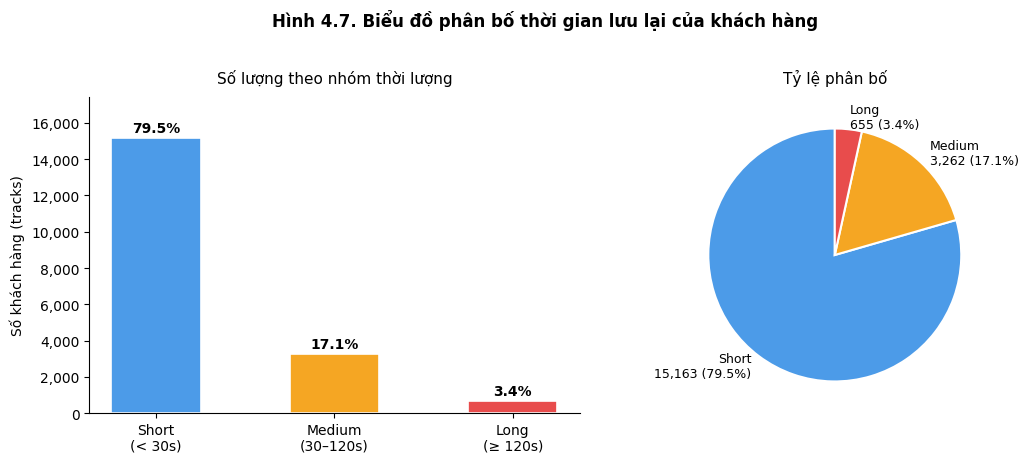

In [10]:
# ── Vẽ Hình 4.7 — Biểu đồ phân bố thời gian lưu lại ─────────────────────────
labels   = ["Short\n(< 30s)", "Medium\n(30–120s)", "Long\n(≥ 120s)"]
values   = [short, medium, long_]
percents = [pct_short, pct_medium, pct_long]
colors   = ["#4C9BE8", "#F5A623", "#E84C4C"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Cột trái: Bar chart ---
ax1 = axes[0]
bars = ax1.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, percents):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax1.set_title("Số lượng theo nhóm thời lượng", fontsize=11, pad=10)
ax1.set_ylabel("Số khách hàng (tracks)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylim(0, max(values) * 1.15)

# --- Cột phải: Pie chart ---
ax2 = axes[1]
wedge_props = {"linewidth": 1.5, "edgecolor": "white"}
ax2.pie(
    values,
    labels=[f"{l}\n{v:,} ({p:.1f}%)"
            for l, v, p in zip(["Short", "Medium", "Long"], values, percents)],
    colors=colors,
    startangle=90,
    wedgeprops=wedge_props,
    textprops={"fontsize": 9},
)
ax2.set_title("Tỷ lệ phân bố", fontsize=11, pad=10)

fig.suptitle(
    "Hình 4.7. Biểu đồ phân bố thời gian lưu lại của khách hàng",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()

out_path = f"{FIG_DIR}/hinh_4_7_dwell_distribution.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Đã lưu: {out_path}")
plt.show()

Tổng rows lấy về: 19,100


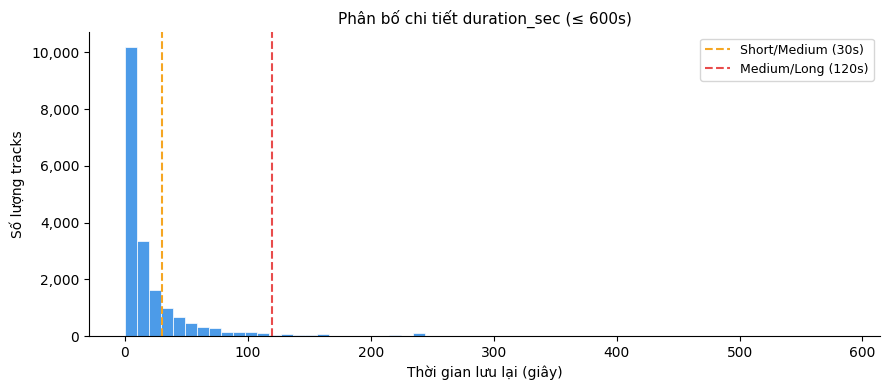

(Histogram tham khảo — không cần đưa vào báo cáo nếu đã có Hình 4.7)


In [11]:
# ── (Tuỳ chọn) Phân bố chi tiết theo histogram ───────────────────────────────
# Lấy tất cả duration_sec để vẽ histogram phân bố liên tục

sql_hist = """
SELECT duration_sec
FROM lakehouse.rva.gold_track_summary_v2
WHERE duration_sec IS NOT NULL
  AND duration_sec <= 600
"""

df_hist = trino_df(sql_hist)
print(f"Tổng rows lấy về: {len(df_hist):,}")

fig2, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_hist["duration_sec"].astype(float), bins=60, color="#4C9BE8",
        edgecolor="white", linewidth=0.5)

# Vẽ đường ngưỡng
ax.axvline(30,  color="#F5A623", linestyle="--", linewidth=1.5, label="Short/Medium (30s)")
ax.axvline(120, color="#E84C4C", linestyle="--", linewidth=1.5, label="Medium/Long (120s)")

ax.set_xlabel("Thời gian lưu lại (giây)")
ax.set_ylabel("Số lượng tracks")
ax.set_title("Phân bố chi tiết duration_sec (≤ 600s)", fontsize=11)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("(Histogram tham khảo — không cần đưa vào báo cáo nếu đã có Hình 4.7)")

---
## 4.3.3 — Thời gian chờ tại khu vực queue (Bảng 4.5 + Hình 4.8)

Dữ liệu từ `gold_queue_sessions` — mỗi row là một lần khách vào khu vực queue.  
Ngưỡng phân loại:
- **Nhanh**    : `wait_time_sec < 30s`
- **Trung bình**: `30s ≤ wait_time_sec < 60s`
- **Chờ lâu**  : `60s ≤ wait_time_sec < 120s`
- **Rất lâu**  : `wait_time_sec ≥ 120s`

In [12]:
# ── Query phân bố thời gian chờ queue ─────────────────────────────────────────
sql_queue = """
SELECT
    SUM(CASE WHEN wait_time_sec < 30                          THEN 1 ELSE 0 END) AS fast_count,
    SUM(CASE WHEN wait_time_sec >= 30  AND wait_time_sec < 60  THEN 1 ELSE 0 END) AS medium_count,
    SUM(CASE WHEN wait_time_sec >= 60  AND wait_time_sec < 120 THEN 1 ELSE 0 END) AS slow_count,
    SUM(CASE WHEN wait_time_sec >= 120                         THEN 1 ELSE 0 END) AS very_slow_count,
    COUNT(*)                                                                       AS total,
    ROUND(AVG(CAST(wait_time_sec AS DOUBLE)), 1)                                  AS avg_wait_sec,
    MAX(wait_time_sec)                                                             AS max_wait_sec
FROM lakehouse.rva.gold_queue_sessions
WHERE wait_time_sec IS NOT NULL
"""

df_queue = trino_df(sql_queue)
display(df_queue)

,fast_count,medium_count,slow_count,very_slow_count,total,avg_wait_sec,max_wait_sec
0,218,23,49,17,307,30.7,219


Tổng phiên queue: 307  |  Avg wait: 30.7s  |  Max wait: 219s



Nhóm,Số phiên,Tỷ lệ
Nhanh (< 30s),218,71.0%
Trung bình (30–60s),23,7.5%
Chờ lâu (60–120s),49,16.0%
Rất lâu (≥ 120s),17,5.5%


→ Copy bảng trên vào Bảng 4.5 trong báo cáo.

Đã lưu: ./hinh_4_8_queue_wait_distribution.png


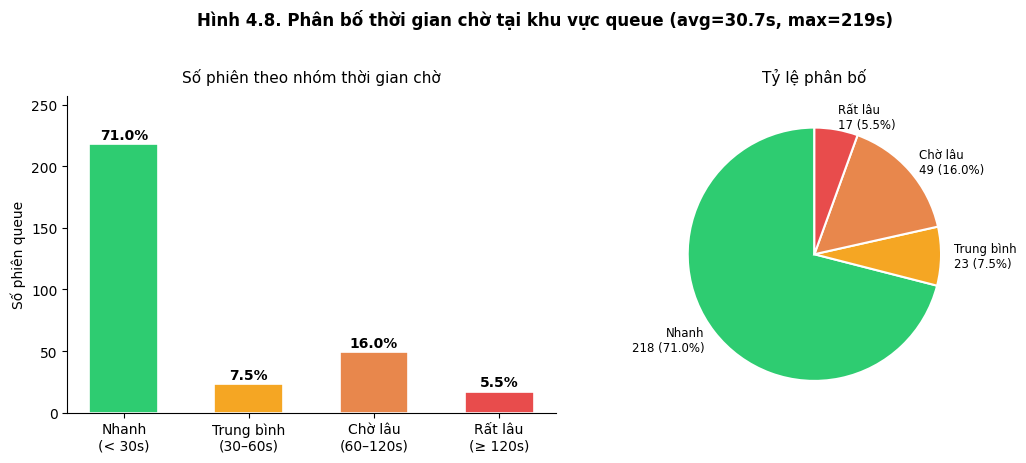

In [13]:
# ── Bảng 4.5 + Hình 4.8 — Phân bố thời gian chờ queue ────────────────────────
fast_c   = int(df_queue["fast_count"].iloc[0])
medium_c = int(df_queue["medium_count"].iloc[0])
slow_c   = int(df_queue["slow_count"].iloc[0])
vslow_c  = int(df_queue["very_slow_count"].iloc[0])
total_q  = int(df_queue["total"].iloc[0])
avg_wait = float(df_queue["avg_wait_sec"].iloc[0])
max_wait = int(df_queue["max_wait_sec"].iloc[0])

vals_q   = [fast_c, medium_c, slow_c, vslow_c]
pcts_q   = [v / total_q * 100 if total_q else 0 for v in vals_q]
labels_q = ["Nhanh\n(< 30s)", "Trung bình\n(30–60s)", "Chờ lâu\n(60–120s)", "Rất lâu\n(≥ 120s)"]
colors_q = ["#2ECC71", "#F5A623", "#E8874C", "#E84C4C"]

# -- In Bảng 4.5
df_table45 = pd.DataFrame([
    {"Nhóm": "Nhanh (< 30s)",        "Số phiên": fast_c,   "Tỷ lệ": f"{pcts_q[0]:.1f}%"},
    {"Nhóm": "Trung bình (30–60s)",   "Số phiên": medium_c, "Tỷ lệ": f"{pcts_q[1]:.1f}%"},
    {"Nhóm": "Chờ lâu (60–120s)",     "Số phiên": slow_c,   "Tỷ lệ": f"{pcts_q[2]:.1f}%"},
    {"Nhóm": "Rất lâu (≥ 120s)",     "Số phiên": vslow_c,  "Tỷ lệ": f"{pcts_q[3]:.1f}%"},
])
print(f"Tổng phiên queue: {total_q:,}  |  Avg wait: {avg_wait}s  |  Max wait: {max_wait}s\n")
display(df_table45.style.hide(axis="index"))
print("→ Copy bảng trên vào Bảng 4.5 trong báo cáo.\n")

# -- Vẽ Hình 4.8
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax1 = axes[0]
bars = ax1.bar(labels_q, vals_q, color=colors_q, width=0.55, edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, pcts_q):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(vals_q) * 0.01,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax1.set_title("Số phiên theo nhóm thời gian chờ", fontsize=11, pad=10)
ax1.set_ylabel("Số phiên queue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylim(0, max(vals_q) * 1.18)

ax2 = axes[1]
ax2.pie(
    vals_q,
    labels=[f"{l.replace(chr(10), ' ')}\n{v:,} ({p:.1f}%)"
            for l, v, p in zip(["Nhanh", "Trung bình", "Chờ lâu", "Rất lâu"], vals_q, pcts_q)],
    colors=colors_q,
    startangle=90,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
    textprops={"fontsize": 8.5},
)
ax2.set_title("Tỷ lệ phân bố", fontsize=11, pad=10)

fig.suptitle(
    f"Hình 4.8. Phân bố thời gian chờ tại khu vực queue (avg={avg_wait}s, max={max_wait}s)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()

out_path = f"{FIG_DIR}/hinh_4_8_queue_wait_distribution.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Đã lưu: {out_path}")
plt.show()

---
## 4.3.4 — Lưu lượng khách hàng theo giờ (Bảng 4.6 + Hình 4.9)

Dữ liệu từ `gold_serving_traffic_hourly` — tổng hợp lưu lượng theo từng khung giờ trong ngày.  
`unique_tracks` = số lượng người duy nhất (đã dedup theo track ID) trong giờ đó.

In [14]:
# ── Query lưu lượng theo giờ trong ngày ───────────────────────────────────────
sql_traffic = """
SELECT
    hour_of_day,
    SUM(unique_tracks)                                       AS total_tracks,
    ROUND(AVG(avg_people_count), 1)                         AS avg_concurrent,
    MAX(max_people_count)                                    AS peak_concurrent,
    SUM(detection_count)                                     AS total_detections
FROM lakehouse.rva_gold_serving.gold_serving_traffic_hourly
GROUP BY hour_of_day
ORDER BY hour_of_day
"""

df_traffic = trino_df(sql_traffic)
print(f"Số khung giờ có data: {len(df_traffic)}")
display(df_traffic)

Số khung giờ có data: 4


,hour_of_day,total_tracks,avg_concurrent,peak_concurrent,total_detections
0,19,238,14.0,31,11504
1,20,3477,10.9,31,168713
2,21,3994,11.4,30,199953
3,22,3879,11.1,29,209340


Giờ cao điểm: 21:00–22:00  (3,994 tracks)



Khung giờ,Khách duy nhất (tracks),Avg đồng thời,Peak đồng thời
19:00–20:00,238,14.000000,31
20:00–21:00,"3,477",10.900000,31
21:00–22:00,"3,994",11.400000,30
22:00–23:00,"3,879",11.100000,29


→ Copy bảng trên vào Bảng 4.6 trong báo cáo.

Đã lưu: ./hinh_4_9_traffic_hourly.png


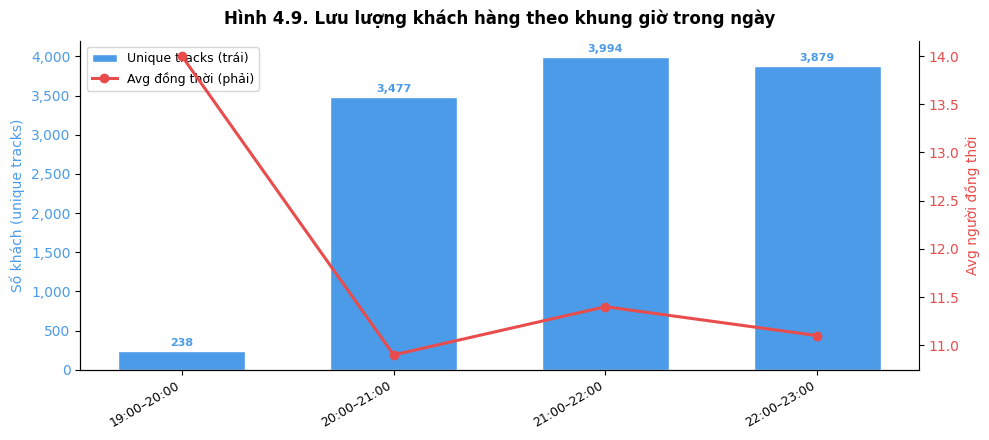

In [15]:
# ── Bảng 4.6 + Hình 4.9 — Lưu lượng theo giờ ────────────────────────────────
hours        = df_traffic["hour_of_day"].astype(int).tolist()
tracks_list  = df_traffic["total_tracks"].astype(int).tolist()
avg_conc     = df_traffic["avg_concurrent"].astype(float).tolist()
peak_conc    = df_traffic["peak_concurrent"].astype(int).tolist()

# -- Bảng 4.6: in dạng giờ → số khách
hour_labels  = [f"{h:02d}:00–{h+1:02d}:00" for h in hours]
peak_idx     = tracks_list.index(max(tracks_list))

df_table46 = pd.DataFrame({
    "Khung giờ":              hour_labels,
    "Khách duy nhất (tracks)": [f"{v:,}" for v in tracks_list],
    "Avg đồng thời":           avg_conc,
    "Peak đồng thời":          peak_conc,
})
print(f"Giờ cao điểm: {hour_labels[peak_idx]}  ({tracks_list[peak_idx]:,} tracks)\n")
display(df_table46.style.hide(axis="index"))
print("→ Copy bảng trên vào Bảng 4.6 trong báo cáo.\n")

# -- Hình 4.9: bar chart + line overlay
fig, ax1 = plt.subplots(figsize=(10, 4.5))

bar_color = "#4C9BE8"
line_color = "#E84C4C"

x = range(len(hours))
bars = ax1.bar(x, tracks_list, color=bar_color, width=0.6,
               edgecolor="white", linewidth=1.0, label="Unique tracks (trái)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(hour_labels, rotation=30, ha="right", fontsize=9)
ax1.set_ylabel("Số khách (unique tracks)", color=bar_color)
ax1.tick_params(axis="y", labelcolor=bar_color)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax1.spines[["top", "right"]].set_visible(False)

# Gắn nhãn trên bar
for xi, v in zip(x, tracks_list):
    ax1.text(xi, v + max(tracks_list) * 0.01, f"{v:,}",
             ha="center", va="bottom", fontsize=8, fontweight="bold", color=bar_color)

# Trục phải: avg concurrent
ax2 = ax1.twinx()
ax2.plot(list(x), avg_conc, color=line_color, linewidth=2.2,
         marker="o", markersize=6, label="Avg đồng thời (phải)")
ax2.set_ylabel("Avg người đồng thời", color=line_color)
ax2.tick_params(axis="y", labelcolor=line_color)
ax2.spines[["top"]].set_visible(False)

# Legend kết hợp
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title(
    "Hình 4.9. Lưu lượng khách hàng theo khung giờ trong ngày",
    fontsize=12, fontweight="bold", pad=12
)
plt.tight_layout()

out_path = f"{FIG_DIR}/hinh_4_9_traffic_hourly.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Đã lưu: {out_path}")
plt.show()

---
## Checklist sau khi chạy xong

| Mục | File / Việc cần làm |
|-----|---------------------|
| Bảng 4.3 | Copy số từ cell `4.3.1` → cập nhật Word |
| Bảng 4.4 | Copy số từ cell `4.3.2` → cập nhật Word |
| Hình 4.7  | Chèn `hinh_4_7_dwell_distribution.png` → Word |
| Bảng 4.5 | Copy số từ cell `4.3.3` → cập nhật Word |
| Hình 4.8  | Chèn `hinh_4_8_queue_wait_distribution.png` → Word |
| Bảng 4.6 | Copy số từ cell `4.3.4` → cập nhật Word |
| Hình 4.9  | Chèn `hinh_4_9_traffic_hourly.png` → Word |
| Số hiệu hình | Kiểm tra caption Hình 4.7 / 4.8 / 4.9 trong Word |